# Module 3, Assignment 1

## Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset information:

## Data Loading and Inspection

NOTE: 
- This dataset doesn't come with column names, here I have created a list with column names and when you use read_csv function, use the proper parameter to assign the column names to the dataframe.

In [2]:
# Download the dataset and load it into a DataFrame

# URL of the Heart Disease UCI dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names for the dataset
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


### Exercise 1: Loading and Inspecting Data

1. Load the dataset into a Pandas DataFrame.
2. Display the first 5 rows of the DataFrame.
3. Drop the column called `target`.
4. Show a summary of the DataFrame, including column data types and non-null values.

---


NOTE: 
- In this dataset, besides null values, we have some columns that have '?' in the csv file. There is a way to replace a string with a null value. Check the parameters of the read_csv function to use the appropriate parameter for this purpose.

In [3]:
# Read the dataset into a pandas DataFrame
df = pd.read_csv(url, names=column_names, na_values='?')

In [4]:
# Display the first five rows of the DataFrame
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# Drop the 'target' column
df = df.drop(columns=['target'])

In [6]:
# Show a summary of the DataFrame, including column data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(13)
memory usage: 30.9 KB


## Data Cleaning Manipulation

### Exercise 2: Data Cleaning
1. Drop the rows with missing values.
2. Drop the duplicated rows.

---

In [7]:
# Remove rows with missing values
df = df.dropna()

In [8]:
# Drop duplicated rows
df = df.drop_duplicates()

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
dtypes: float64(13)
memory usage: 32.5 KB


## Data Manupulation and Feature Engineering

### Exercise 3: Creating new feature 
1. Create a new feature 'AgeGroup' based on the 'age' column with the following labels: 'Young', 'Middle-aged', 'Senior'. Learn how to use an int for bins parameter in the pd.cut() function to create the age groups.
2. Create a new feature 'HeartHealth' using the 'apply' function and the following conditions:\
    Conditions: Good if thalach > 150 and chol < 240, Poor otherwise
3. Create a new feature 'RiskFactor' using the following formula:\
    RiskFactor = age * (chol + thalach)

---

Here is the cut funtion with two main arameters:

pd.cut(x, bins)

x : array-like
The input array to be binned. Must be 1-dimensional.

bins : int, sequence of scalars, or IntervalIndex

    - The criteria to bin by.

    1) int : Defines the number of equal-width bins in the range of x. The range of x is extended by .1% on each side to include the minimum and maximum values of x.

    2) sequence of scalars : Defines the bin edges allowing for non-uniform width. No extension of the range of x is done.

    3) IntervalIndex : Defines the exact bins to be used. Note that IntervalIndex for bins

In [10]:
# Create a new feature 'AgeGroup' based on the 'age' column with the following labels: 'Young', 'Middle-aged', 'Senior'
# bins=3 splits the age range into 3 equal-width groups automatically
df['AgeGroup'] = pd.cut(df['age'], bins=3, labels=['Young', 'Middle-aged', 'Senior'])

In [11]:
# Create a new feature 'HeartHealth' using the 'apply' function and the following conditions:
# Conditions: Good if thalach > 150 and chol < 240, Poor otherwise
df['HeartHealth'] = df.apply(lambda row: 'Good' if row['thalach'] > 150 and row['chol'] < 240 else 'Poor', axis=1)

In [12]:
# Create a new feature 'RiskFactor' using the following formula: RiskFactor = age * (chol + thalach)
df['RiskFactor'] = df['age'] * (df['chol'] + df['thalach'])

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,AgeGroup,HeartHealth,RiskFactor
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,Senior,Poor,24129.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,Senior,Poor,26398.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,Senior,Poor,23986.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,Young,Poor,16169.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,Young,Good,15416.0


## Data Visualization

### Exercise 4: Drawing plots with Pyplot module functions and Pandas plot method
1. Draw a line plot of the 'trestbps' column for the first 50 rows.
2. Draw a line plot of average 'trestbps' for each 'age' group.
3. Draw a scatter plot showing the Relationship between Age and Risk Factor.
4. Crate a dataframe with the count of 'HeartHealth' for each 'AgeGroup' using the 'groupby' function. Learn about size() and unstack() functions.
5. Draw a stacked bar plot showing the HeartHealth distribution within each Age group as the x-axis and the 'Good' and 'Poor' categories stacked for each age group. Add a legend to the plot. 
6. Draw a histogram showing the distribution of patient ages. Set bins to 20 and color to 'skyblue'. Learn how to use the 'edgecolor' parameter to add a border to the bars.
7. Draw a pie chart showing the percentage distribution of the 'AgeGroup' column. Learn how to use the 'autopct' parameter to display the percentage value and the 'startangle' parameter to rotate the pie chart.
8. Draw a box plot showing the distribution of 'thalach' across different 'cp' values. Learn how to use the 'patch_artist' parameter to fill the boxes with color.

---

#### 1. Line Plot of Trend of Resting Blood Pressure for first 50 rows

-  Creat the data that is needed for the plot by slicing the DataFrame to get the first 50 rows of the 'trestbps' column

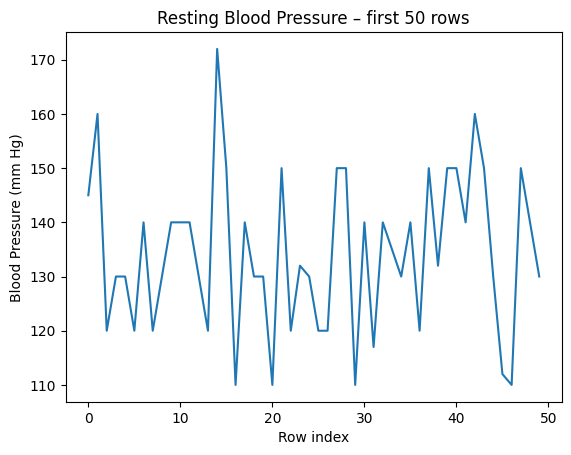

In [14]:
# Draw a line plot of the 'trestbps' column for the first 50 rows

# Data preparation
data = df['trestbps'].iloc[:50]

# Call the plot function
plt.plot(data)

# Additional customizations
plt.title('Resting Blood Pressure – first 50 rows')
plt.xlabel('Row index')
plt.ylabel('Blood Pressure (mm Hg)')

plt.show()

#### 2. Line plot of average Trend of Resting Blood Pressure

This line plot illustrates the average trend of Resting Blood Pressure (trestbps) across different age groups.
- X-Axis: Age
- Y-Axis: Average Resting Blood Pressure


NOTE: Use groupby to group the data by 'age' and calculate the mean of 'trestbps'.

The marker 'o' indicates individual data points.

The plot provides insight into how the average Resting Blood Pressure changes with increasing age.

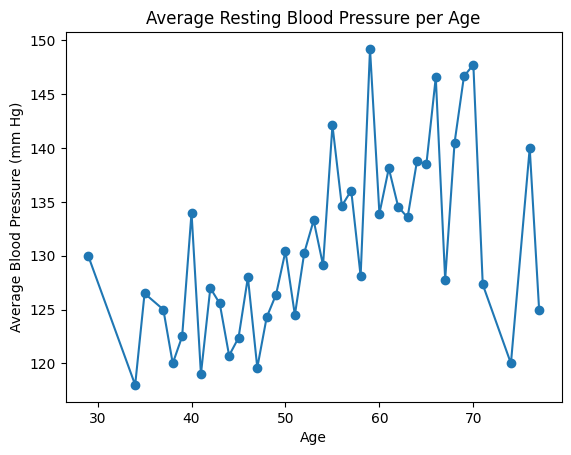

In [15]:
# Draw a line plot of average 'trestbps' for each 'age' group

# Data preparation – group by age and calculate the mean trestbps
avg_trestbps = df.groupby('age')['trestbps'].mean()

# Call the plot function
plt.plot(avg_trestbps.index, avg_trestbps.values, marker='o')

# Additional customizations
plt.title('Average Resting Blood Pressure per Age')
plt.xlabel('Age')
plt.ylabel('Average Blood Pressure (mm Hg)')

plt.show()

#### 3. Scatter Plot

This scatter plot visually explores the relationship between Age and Risk Factor.
- X-Axis: Age
- Y-Axis: Risk Factor

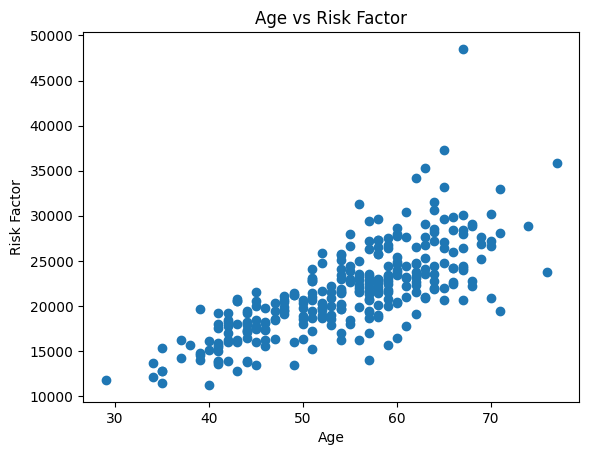

In [16]:
# Draw a scatter plot showing the Relationship between Age and Risk Factor

# Data preparation
x = df['age']
y = df['RiskFactor']

# Plot the scatter
plt.scatter(x, y)

# Additional customizations
plt.title('Age vs Risk Factor')
plt.xlabel('Age')
plt.ylabel('Risk Factor')

plt.show()

#### 4. Create a dataframe using groupby

In [17]:
# Create a dataframe with the count of 'HeartHealth' for each 'AgeGroup' using the 'groupby' function
# size() counts the combinations, unstack() pivots HeartHealth into columns
health_age_df = df.groupby(['AgeGroup', 'HeartHealth']).size().unstack()
health_age_df

HeartHealth,Good,Poor
AgeGroup,,
Young,30,31
Middle-aged,43,122
Senior,5,66


#### 5. Bar Plot

This stacked bar plot represents the distribution of HeartHealth (Good or Poor) within each Age group.
- X-Axis: Age Group
- Y-Axis: Count

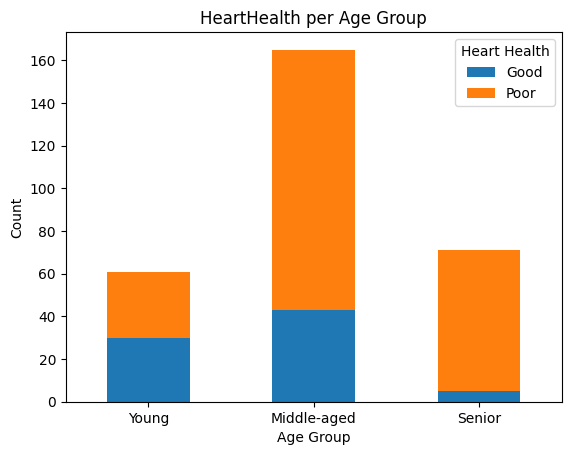

In [18]:
# Draw a stacked bar plot showing the HeartHealth distribution within each Age group

# Data preparation – use the dataframe from the previous cell
# health_age_df already has AgeGroup as index and Good/Poor as columns

# Plotting the bars
health_age_df.plot(kind='bar', stacked=True)

# Additional customizations
plt.title('HeartHealth per Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.legend(title='Heart Health')
plt.show()

### 6. Histogram Plot

This histogram visually displays the distribution of patient ages in the dataset.
- X-Axis: Age
- Y-Axis: Frequency (Number of individuals)

The histogram provides a visual representation of how patient ages are distributed in the dataset.
The 'skyblue' color represents the bars, and each bar corresponds to an age group.

The number of bins (20) determines the granularity of the age distribution.

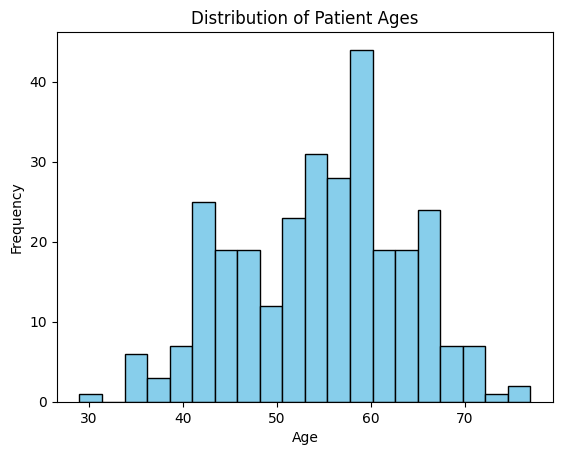

In [19]:
# Draw a histogram showing the distribution of patient ages

# Data preparation
ages = df['age']

# Call the hist function
plt.hist(ages, bins=20, color='skyblue', edgecolor='black')

# Additional customizations
plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

### 7. Pie Chart

This pie chart visually represents the percentage distribution of individuals across different age groups.

- Each slice of the pie corresponds to a specific age group (Young, Middle-aged, Senior).
- The 'skyblue', 'orange', and 'lightgreen' colors distinguish between the age groups.
- The percentage labels on each slice indicate the proportion of individuals in each age category relative to the total.
- The startangle parameter (90 degrees) adjusts the starting position of the first slice.

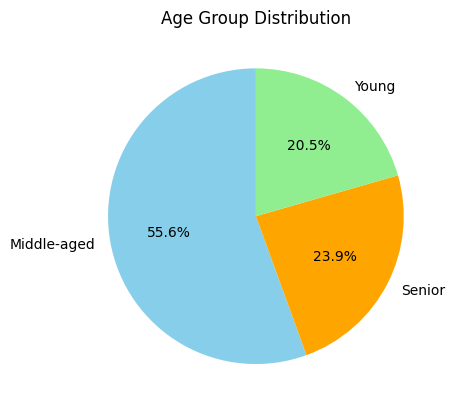

In [20]:
# Draw a pie chart showing the percentage distribution of the 'AgeGroup' column

# Data preparation – count how many patients fall in each age group
age_group_counts = df['AgeGroup'].value_counts()

# Call the pie function
plt.pie(age_group_counts, labels=age_group_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['skyblue', 'orange', 'lightgreen'])

# Additional customizations
plt.title('Age Group Distribution')

plt.show()

### 8. Box Plot

This box plot visually represents the distribution of Maximum Heart Rate (thalach) for different chest pain types.
- X-Axis: Chest Pain Type
- Y-Axis: Maximum Heart Rate

The box plot shows the central tendency and spread of Maximum Heart Rate for each chest pain type.

Chest pain types are labeled on the x-axis, and the y-axis represents Maximum Heart Rate values.

The boxes indicate the interquartile range (IQR), while the horizontal line inside the box represents the median.

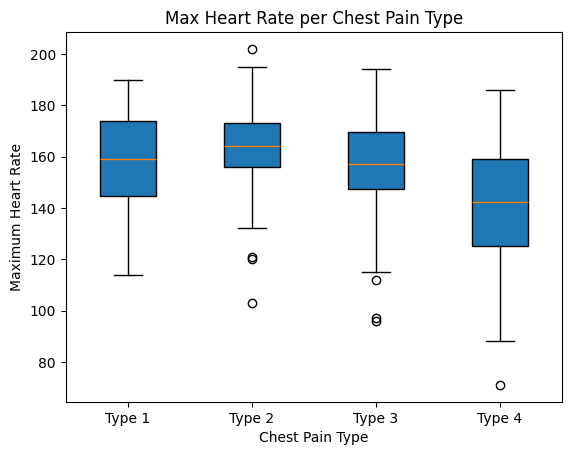

In [21]:
# Draw a box plot showing the distribution of 'thalach' across different 'cp' values

# Data preparation

# Get unique values of 'cp'
cp_values = sorted(df['cp'].unique())  # this will return a list of unique values in the 'cp' column

# Separate values for boxplot_data
# Combine them into a list
boxplot_data = [df[df['cp'] == cp]['thalach'].values for cp in cp_values]

# Call the boxplot function
bp = plt.boxplot(boxplot_data, patch_artist=True)

# Additional customizations
plt.title('Max Heart Rate per Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Maximum Heart Rate')
plt.xticks(range(1, len(cp_values) + 1), [f'Type {int(cp)}' for cp in cp_values])

plt.show()